# ANÁLISIS EDA POST-LIMPIEZA

Este documento presenta la segunda fase del Análisis Exploratorio de Datos (EDA) aplicado al conjunto de datos de consumo energético. Su objetivo principal es caracterizar la distribución, variabilidad y heterogeneidad de las variables numéricas, fundamentales para determinar las estrategias adecuadas de preprocesamiento e imputación de datos faltantes.

El análisis incluye:

* Medidas de tendencia central: Resumen de media, mediana, moda, valores mínimos y máximos.

* Análisis de dispersión y posición: Cálculo de rangos, cuartiles (Q1, Q2, Q3), varianza, desviación estándar y coeficiente de variación (CV), excluyendo variables binarias para mayor relevancia estadística.

* Forma de la distribución: Evaluación de asimetría (Skewness) y exceso de curtosis, complementada con histogramas para la visualización de patrones, sesgos y detección de valores atípicos.

Este reporte permite identificar qué variables presentan alta variabilidad (indicada por un CV elevado), orientando la selección de métodos de limpieza y tratamiento de nulos más robustos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

bd = pd.read_csv("/content/dataset_consumo_energetico_LIMPIO.csv")

In [ ]:
bd.isna().sum().sum()

np.int64(186939)

## Medidas de tendencia central y posición

Como primera etapa del Análisis Exploratorio de Datos (EDA), se calcularon las principales medidas de tendencia central y de posición para todas las variables numéricas del conjunto de datos. El propósito de este análisis es obtener una descripción general del comportamiento de cada variable, identificar posibles patrones en la distribución de los datos y proporcionar información que sirva de apoyo para las etapas posteriores del análisis, especialmente en la definición de estrategias de imputación de valores faltantes.

Inicialmente, el procedimiento identifica automáticamente todas las variables numéricas presentes en el DataFrame `bd`, incluyendo tanto variables enteras como decimales. De esta manera, el análisis se adapta dinámicamente a la estructura del conjunto de datos sin necesidad de especificar manualmente cada variable.

Para cada una de las variables seleccionadas se calcula el número de valores nulos existentes, permitiendo conocer la magnitud de la información faltante antes de realizar cualquier procedimiento de imputación.

Posteriormente, se obtienen las principales medidas descriptivas de la distribución de los datos. En primer lugar, se determina el valor mínimo observado, correspondiente al menor valor registrado para la variable. A continuación, se calcula la media aritmética, que representa el promedio de los datos y constituye una medida del centro de la distribución. Seguidamente, se obtiene la mediana, definida como el valor central de la distribución una vez ordenados los datos, siendo una medida menos sensible a la presencia de valores atípicos. También se calcula la moda, correspondiente al valor que presenta la mayor frecuencia de aparición dentro de la variable. Finalmente, se determina el valor máximo observado, representando el mayor valor registrado para dicha variable.

Todos los cálculos estadísticos se realizan utilizando la máxima precisión disponible, considerando únicamente los valores válidos y omitiendo automáticamente los datos faltantes (`NaN`). Posteriormente, los resultados se redondean únicamente para su presentación, mostrando dos cifras decimales con el fin de facilitar su interpretación sin afectar la precisión de los cálculos realizados.

Como resultado del procedimiento se genera una tabla resumen en la que cada fila corresponde a una variable numérica y cada columna presenta el número de valores nulos, el valor mínimo, la media, la mediana, la moda y el valor máximo. Finalmente, se informa el número total de variables numéricas analizadas, proporcionando una visión general del alcance del análisis descriptivo realizado.

In [ ]:
# ==========================================================
# MEDIDAS DE TENDENCIA CENTRAL Y POSICIÓN
# ==========================================================

print("="*80)
print("MEDIDAS DE TENDENCIA CENTRAL")
print("="*80)

# ==========================================================
# Seleccionar variables numéricas
# ==========================================================

variables_numericas = bd.select_dtypes(
    include=["Int64", "Float64", "int64", "float64"]
).columns

# ==========================================================
# Calcular estadísticas
# ==========================================================

reporte = pd.DataFrame({

    "Variable": variables_numericas,

    "Nulos": [
        int(bd[col].isna().sum())
        for col in variables_numericas
    ],

    "Mínimo": [
        bd[col].min(skipna=True)
        for col in variables_numericas
    ],

    "Media": [
        bd[col].mean(skipna=True)
        for col in variables_numericas
    ],

    "Mediana": [
        bd[col].median(skipna=True)
        for col in variables_numericas
    ],

    "Moda": [
        bd[col].mode(dropna=True).iloc[0]
        if not bd[col].mode(dropna=True).empty
        else np.nan
        for col in variables_numericas
    ],

    "Máximo": [
        bd[col].max(skipna=True)
        for col in variables_numericas
    ]

})

# ==========================================================
# Redondear únicamente para mostrar resultados
# ==========================================================

columnas_numericas = [
    "Mínimo",
    "Media",
    "Mediana",
    "Moda",
    "Máximo"
]

reporte[columnas_numericas] = (
    reporte[columnas_numericas]
    .astype(float)
    .round(2)
)

# ==========================================================
# Mostrar resultados
# ==========================================================

display(reporte)

print("\nResumen")
print(f"Variables numéricas analizadas: {len(variables_numericas)}")

MEDIDAS DE TENDENCIA CENTRAL


,Variable,Nulos,Mínimo,Media,Mediana,Moda,Máximo
0,num_personas,2155,1.00,3.79,3.00,3.00,88.00
1,superficie_m2,7809,25.00,111.00,94.70,25.00,9778.30
2,antiguedad_construccion_anios,3428,0.00,20.13,20.00,31.00,150.00
3,dias_facturacion,2124,28.00,30.12,30.00,30.00,31.00
4,temperatura_promedio_c,10675,22.50,27.81,27.90,28.50,32.90
5,tiene_aire_acondicionado,6896,0.00,0.64,1.00,1.00,1.00
6,cantidad_unidades_aa,1101,0.00,1.35,1.00,0.00,6.00
7,horas_uso_aa_dia,4527,0.00,4.59,5.20,0.00,16.00
8,tiene_calentador_agua_electrico,6656,0.00,0.22,0.00,0.00,1.00
9,tiene_lavadora,6725,0.00,0.58,1.00,1.00,1.00



Resumen
Variables numéricas analizadas: 34


A partir de las estadísticas descriptivas, se observa que, tras el proceso de limpieza de datos, no existen valores fuera de rangos lógicos en las variables analizadas. Por ejemplo, la variable costo_estimado_usd presenta un valor mínimo mayor o igual a 0, lo que indica la ausencia de registros con costos negativos.

Asimismo, las estadísticas descriptivas permiten corroborar la elevada presencia de valores np.nan en variables como certificacion_energetica_previa y temperatura_promedio_c, lo que coincide con los resultados obtenidos en el análisis previo de valores faltantes.

## Medidas de dispersión y posición

Como segunda etapa del Análisis Exploratorio de Datos (EDA), se calcularon las principales medidas de dispersión y posición para las variables numéricas del conjunto de datos. El objetivo de este análisis es cuantificar la variabilidad de los datos, evaluar la distribución de sus valores y caracterizar el grado de heterogeneidad presente en cada variable, proporcionando información relevante para la identificación de valores atípicos y para la selección de estrategias de preprocesamiento e imputación.

Inicialmente, el procedimiento identifica automáticamente todas las variables numéricas presentes en el DataFrame `bd`. Posteriormente, se excluyen del análisis aquellas variables que representan información binaria o booleana, es decir, aquellas cuyos valores corresponden únicamente a los estados 0 y 1 o cuya cardinalidad es igual o inferior a dos valores distintos. Esta exclusión se realiza debido a que las medidas de dispersión calculadas carecen de una interpretación estadística relevante para variables dicotómicas. Asimismo, se omiten variables de identificación, como `id_registro`, al no representar información cuantitativa susceptible de análisis descriptivo.

Para cada una de las variables seleccionadas se contabiliza el número de valores faltantes (`NaN`) y posteriormente se calculan diversas medidas estadísticas utilizando exclusivamente los registros válidos.

En primer lugar, se determina el rango de la distribución, obtenido como la diferencia entre el valor máximo y el valor mínimo de la variable. A continuación, se calculan los cuartiles de la distribución: el primer cuartil (Q1), correspondiente al percentil 25; el segundo cuartil (Q2), equivalente a la mediana; y el tercer cuartil (Q3), correspondiente al percentil 75. Estas medidas permiten describir la distribución de los datos y constituyen la base para la posterior identificación de valores atípicos mediante el rango intercuartílico.

Seguidamente, se calcula la varianza muestral, la cual cuantifica la dispersión promedio de los datos respecto a su media. Posteriormente, se obtiene la desviación estándar, expresada en las mismas unidades de la variable original, facilitando la interpretación de la variabilidad observada.

Finalmente, se calcula el coeficiente de variación (CV), definido como la relación entre la desviación estándar y la media de la variable. Esta medida permite comparar la variabilidad relativa entre variables que poseen diferentes escalas de medición. Cuando la media de una variable es igual a cero, el coeficiente de variación no puede calcularse y, en consecuencia, se registra como un valor faltante (`NaN`).

Todos los cálculos estadísticos se realizan utilizando la máxima precisión disponible en punto flotante. Únicamente durante la presentación de los resultados los valores son redondeados a dos cifras decimales, preservando la precisión de los cálculos originales y facilitando la interpretación de las tablas generadas.

Como resultado del procedimiento se obtiene una tabla resumen que presenta, para cada variable numérica analizada, el número de valores faltantes, el rango de la distribución, los cuartiles (Q1, Q2 y Q3), la varianza, la desviación estándar y el coeficiente de variación. Adicionalmente, se informa el número de variables cuantitativas analizadas y el número de variables binarias excluidas del cálculo, proporcionando una visión general del alcance del análisis descriptivo realizado.

In [ ]:
# ==========================================================
# CÁLCULO DE MEDIDAS DE DISPERSIÓN Y POSICIÓN (SIN BINARIAS)
# ==========================================================

print("="*80)
print("ESTADÍSTICAS DE POSICIÓN Y DISPERSIÓN (EXCLUYENDO VARIABLES BINARIAS: 0 Y 1)")
print("="*80)

# 1. Selección de columnas numéricas (enteras, flotantes y booleanas normalizadas)
columnas_numericas = bd.select_dtypes(include=["Int64", "Float64", "int64", "float64"]).columns

estadisticas = []
variables_excluidas = 0

for col in columnas_numericas:
    # Omitimos variables de identificación si estuvieran presentes
    if col in ["Unnamed: 0", "id_registro"]:
        continue

    serie = bd[col].dropna().astype(float)

    # 2. FILTRADO INVERSO: Excluir columnas si sus valores son un subconjunto de {0.0, 1.0} o si su cardinalidad es <= 2
    if set(serie.unique()).issubset({0.0, 1.0}) or serie.nunique() <= 2:
        variables_excluidas += 1
        continue

    if len(serie) > 0:
        # 3. Cálculos estadísticos con precisión de punto flotante completa
        val_min = serie.min()
        val_max = serie.max()
        rango = val_max - val_min

        q1 = serie.quantile(0.25)
        q2 = serie.quantile(0.50)  # Mediana (Q2)
        q3 = serie.quantile(0.75)

        varianza = serie.var(ddof=1)
        desviacion = serie.std(ddof=1)
        media = serie.mean()

        # Coeficiente de variación (CV = Desviación Estándar / Media × 100)
        cv = (desviacion / media * 100) if media != 0 else np.nan

        estadisticas.append({
    "Nombre de la variable": col,
    "Nulos": int(bd[col].isna().sum()),
    "Rango": rango,
    "Q1": q1,
    "Q2": q2,
    "Q3": q3,
    "Varianza": varianza,
    "Desviación Estándar": desviacion,
    "Coeficiente de Variación (%)": cv
})

# 4. Creación de la tabla y redondeo selectivo para la presentación visual
df_estadisticas = pd.DataFrame(estadisticas)

columnas_a_redondear = [
    "Rango",
    "Q1",
    "Q2",
    "Q3",
    "Varianza",
    "Desviación Estándar",
    "Coeficiente de Variación (%)"
]

df_estadisticas[columnas_a_redondear] = (
    df_estadisticas[columnas_a_redondear]
    .astype(float)
    .round(2)
)

print(f"-> Variables continuas/discretas analizadas : {len(df_estadisticas)}")
print(f"-> Variables binarias/booleanas excluidas   : {variables_excluidas}\n")

# Renderizado interactivo y limpio en Google Colab
display(df_estadisticas)

ESTADÍSTICAS DE POSICIÓN Y DISPERSIÓN (EXCLUYENDO VARIABLES BINARIAS: 0 Y 1)
-> Variables continuas/discretas analizadas : 30
-> Variables binarias/booleanas excluidas   : 4



,Nombre de la variable,Nulos,Rango,Q1,Q2,Q3,Varianza,Desviación Estándar,Coeficiente de Variación (%)
0,num_personas,2155,87.00,2.00,3.00,5.00,11.79,3.43,90.70
1,superficie_m2,7809,9753.30,69.10,94.70,136.10,18472.98,135.92,122.45
2,antiguedad_construccion_anios,3428,150.00,10.00,20.00,30.00,152.62,12.35,61.38
3,dias_facturacion,2124,3.00,30.00,30.00,31.00,0.62,0.79,2.62
4,temperatura_promedio_c,10675,10.40,26.70,27.90,28.90,2.18,1.48,5.31
5,cantidad_unidades_aa,1101,6.00,0.00,1.00,2.00,2.03,1.43,105.30
6,horas_uso_aa_dia,4527,16.00,0.00,5.20,7.70,15.11,3.89,84.66
7,cantidad_tv_o_pantallas,2121,4.00,1.00,2.00,3.00,1.24,1.11,61.45
8,cantidad_computadoras,2127,3.00,0.00,1.00,2.00,0.83,0.91,84.47
9,pct_iluminacion_led,4482,100.00,28.10,47.60,67.60,708.51,26.62,55.37


En este caso, la información más relevante que proporciona esta tabla corresponde al coeficiente de variación (CV), ya que permite evaluar la variabilidad relativa de cada variable con respecto a su media. Como se observa, algunas variables presentan coeficientes de variación superiores al 100 % e incluso al 1000 %, como ocurre con variacion_pct_consumo_mensual. Esto indica una alta heterogeneidad en la distribución de sus datos, lo que reduce la representatividad de la media como medida de tendencia central.

En consecuencia, la imputación mediante la media aritmética podría ser una alternativa poco adecuada para estas variables. No obstante, esta decisión no debe basarse únicamente en el coeficiente de variación, sino también en otros criterios, como el mecanismo de ausencia de datos y la forma de la distribución, la cual podrá evaluarse mediante histogramas u otras técnicas de análisis exploratorio.

## Análisis de la asimetría, exceso de curtosis e histogramas

Como parte del Análisis Exploratorio de Datos (EDA), se evaluó la forma de la distribución de las variables numéricas mediante el cálculo del coeficiente de asimetría (*Skewness*) y del exceso de curtosis (*Excess Kurtosis*). Adicionalmente, se generó un conjunto de histogramas con el propósito de representar gráficamente la distribución de cada variable y facilitar la interpretación visual de los resultados obtenidos.

En primer lugar, el procedimiento identifica automáticamente todas las variables numéricas presentes en el DataFrame `bd`. Posteriormente, se excluyen del análisis aquellas variables que no resultan apropiadas para este tipo de estudio descriptivo. En particular, se omiten las variables de identificación, como `id_registro`, así como todas aquellas variables cuya cardinalidad es igual o inferior a tres valores distintos. Esta decisión metodológica responde a que variables binarias, ternarias o con muy pocos valores posibles presentan distribuciones discretas cuya asimetría y curtosis carecen de una interpretación estadística relevante en comparación con variables cuantitativas continuas o discretas de mayor variabilidad. Las variables excluidas se registran en una tabla independiente, indicando tanto su cardinalidad como el motivo de su exclusión.

Para cada una de las variables seleccionadas se contabiliza inicialmente el número de valores faltantes (`NaN`). Posteriormente, utilizando únicamente los valores válidos, se calcula el coeficiente de asimetría (*Skewness*), el cual cuantifica el grado y la dirección de la simetría de la distribución de los datos. Un coeficiente positivo indica una distribución con asimetría hacia la derecha, mientras que un coeficiente negativo representa una distribución con asimetría hacia la izquierda. Un valor cercano a cero sugiere una distribución aproximadamente simétrica.

De forma complementaria, se calcula el exceso de curtosis empleando la definición de Fisher implementada por la biblioteca **Pandas**. Esta medida permite caracterizar la concentración de los datos alrededor de la media y el comportamiento de las colas de la distribución. Valores positivos corresponden a distribuciones leptocúrticas, caracterizadas por una mayor concentración central y colas relativamente pesadas; valores iguales a cero indican distribuciones mesocúrticas, similares a una distribución normal; mientras que valores negativos representan distribuciones platicúrticas, con una menor concentración central y colas relativamente ligeras.

Todos los coeficientes estadísticos se calculan utilizando la máxima precisión disponible en punto flotante (`float64`). Con el objetivo de facilitar la interpretación de los resultados sin afectar la precisión de los cálculos, los valores únicamente se redondean a dos cifras decimales durante su presentación en la tabla resumen, conservándose internamente la precisión completa de los cálculos realizados.

La tabla resultante presenta, para cada variable analizada, el número de valores faltantes, el coeficiente de asimetría y el exceso de curtosis. Además, ambas medidas se representan mediante un formato condicional que facilita su interpretación visual. Los coeficientes positivos se resaltan mediante un fondo de color verde oscuro, los coeficientes negativos mediante un fondo azul oscuro y los valores iguales a cero permanecen sin resaltado. En todos los casos se utiliza texto blanco sobre fondos coloreados para mejorar la legibilidad de la información presentada.

Finalmente, el procedimiento genera automáticamente un histograma para cada una de las variables analizadas utilizando las funciones de visualización de **Pandas** y **Matplotlib**. Los histogramas se organizan dinámicamente dentro de una cuadrícula cuyo tamaño se adapta al número de variables presentes, empleando un número uniforme de intervalos para facilitar la comparación entre distribuciones. Estas representaciones gráficas permiten corroborar visualmente los resultados obtenidos mediante los coeficientes de asimetría y curtosis, además de identificar posibles valores atípicos, distribuciones multimodales, sesgos o patrones particulares presentes en los datos.

Como resultado del procedimiento se obtiene una tabla resumen con las principales medidas de forma de la distribución, una tabla con las variables excluidas del análisis y la justificación correspondiente, además de un conjunto de histogramas que proporciona una representación visual del comportamiento estadístico de todas las variables cuantitativas consideradas en esta etapa del Análisis Exploratorio de Datos.

ASIMETRÍA (SKEWNESS) Y EXCESO DE CURTOSIS

Tabla de Skewness y Curtosis



/tmp/ipykernel_2921/692538286.py:114: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(


,Variable,Nulos,Coeficiente de Skewness,Exceso de Curtosis
0,num_personas,2155,13.94,312.98
1,superficie_m2,7809,31.70,1608.52
2,antiguedad_construccion_anios,3428,0.88,8.08
3,dias_facturacion,2124,-1.19,1.69
4,temperatura_promedio_c,10675,-0.07,-0.55
5,cantidad_unidades_aa,1101,1.18,1.02
6,horas_uso_aa_dia,4527,0.10,-1.28
7,cantidad_tv_o_pantallas,2121,0.25,-0.64
8,cantidad_computadoras,2127,0.47,-0.62
9,pct_iluminacion_led,4482,0.07,-0.79



Variables excluidas del análisis



,Variable,Cardinalidad,Motivo
0,tiene_aire_acondicionado,2,Cardinalidad ≤ 3
1,tiene_calentador_agua_electrico,2,Cardinalidad ≤ 3
2,tiene_lavadora,2,Cardinalidad ≤ 3
3,certificacion_energetica_previa,2,Cardinalidad ≤ 3



Variables analizadas            : 30
Variables excluidas            : 4

HISTOGRAMAS


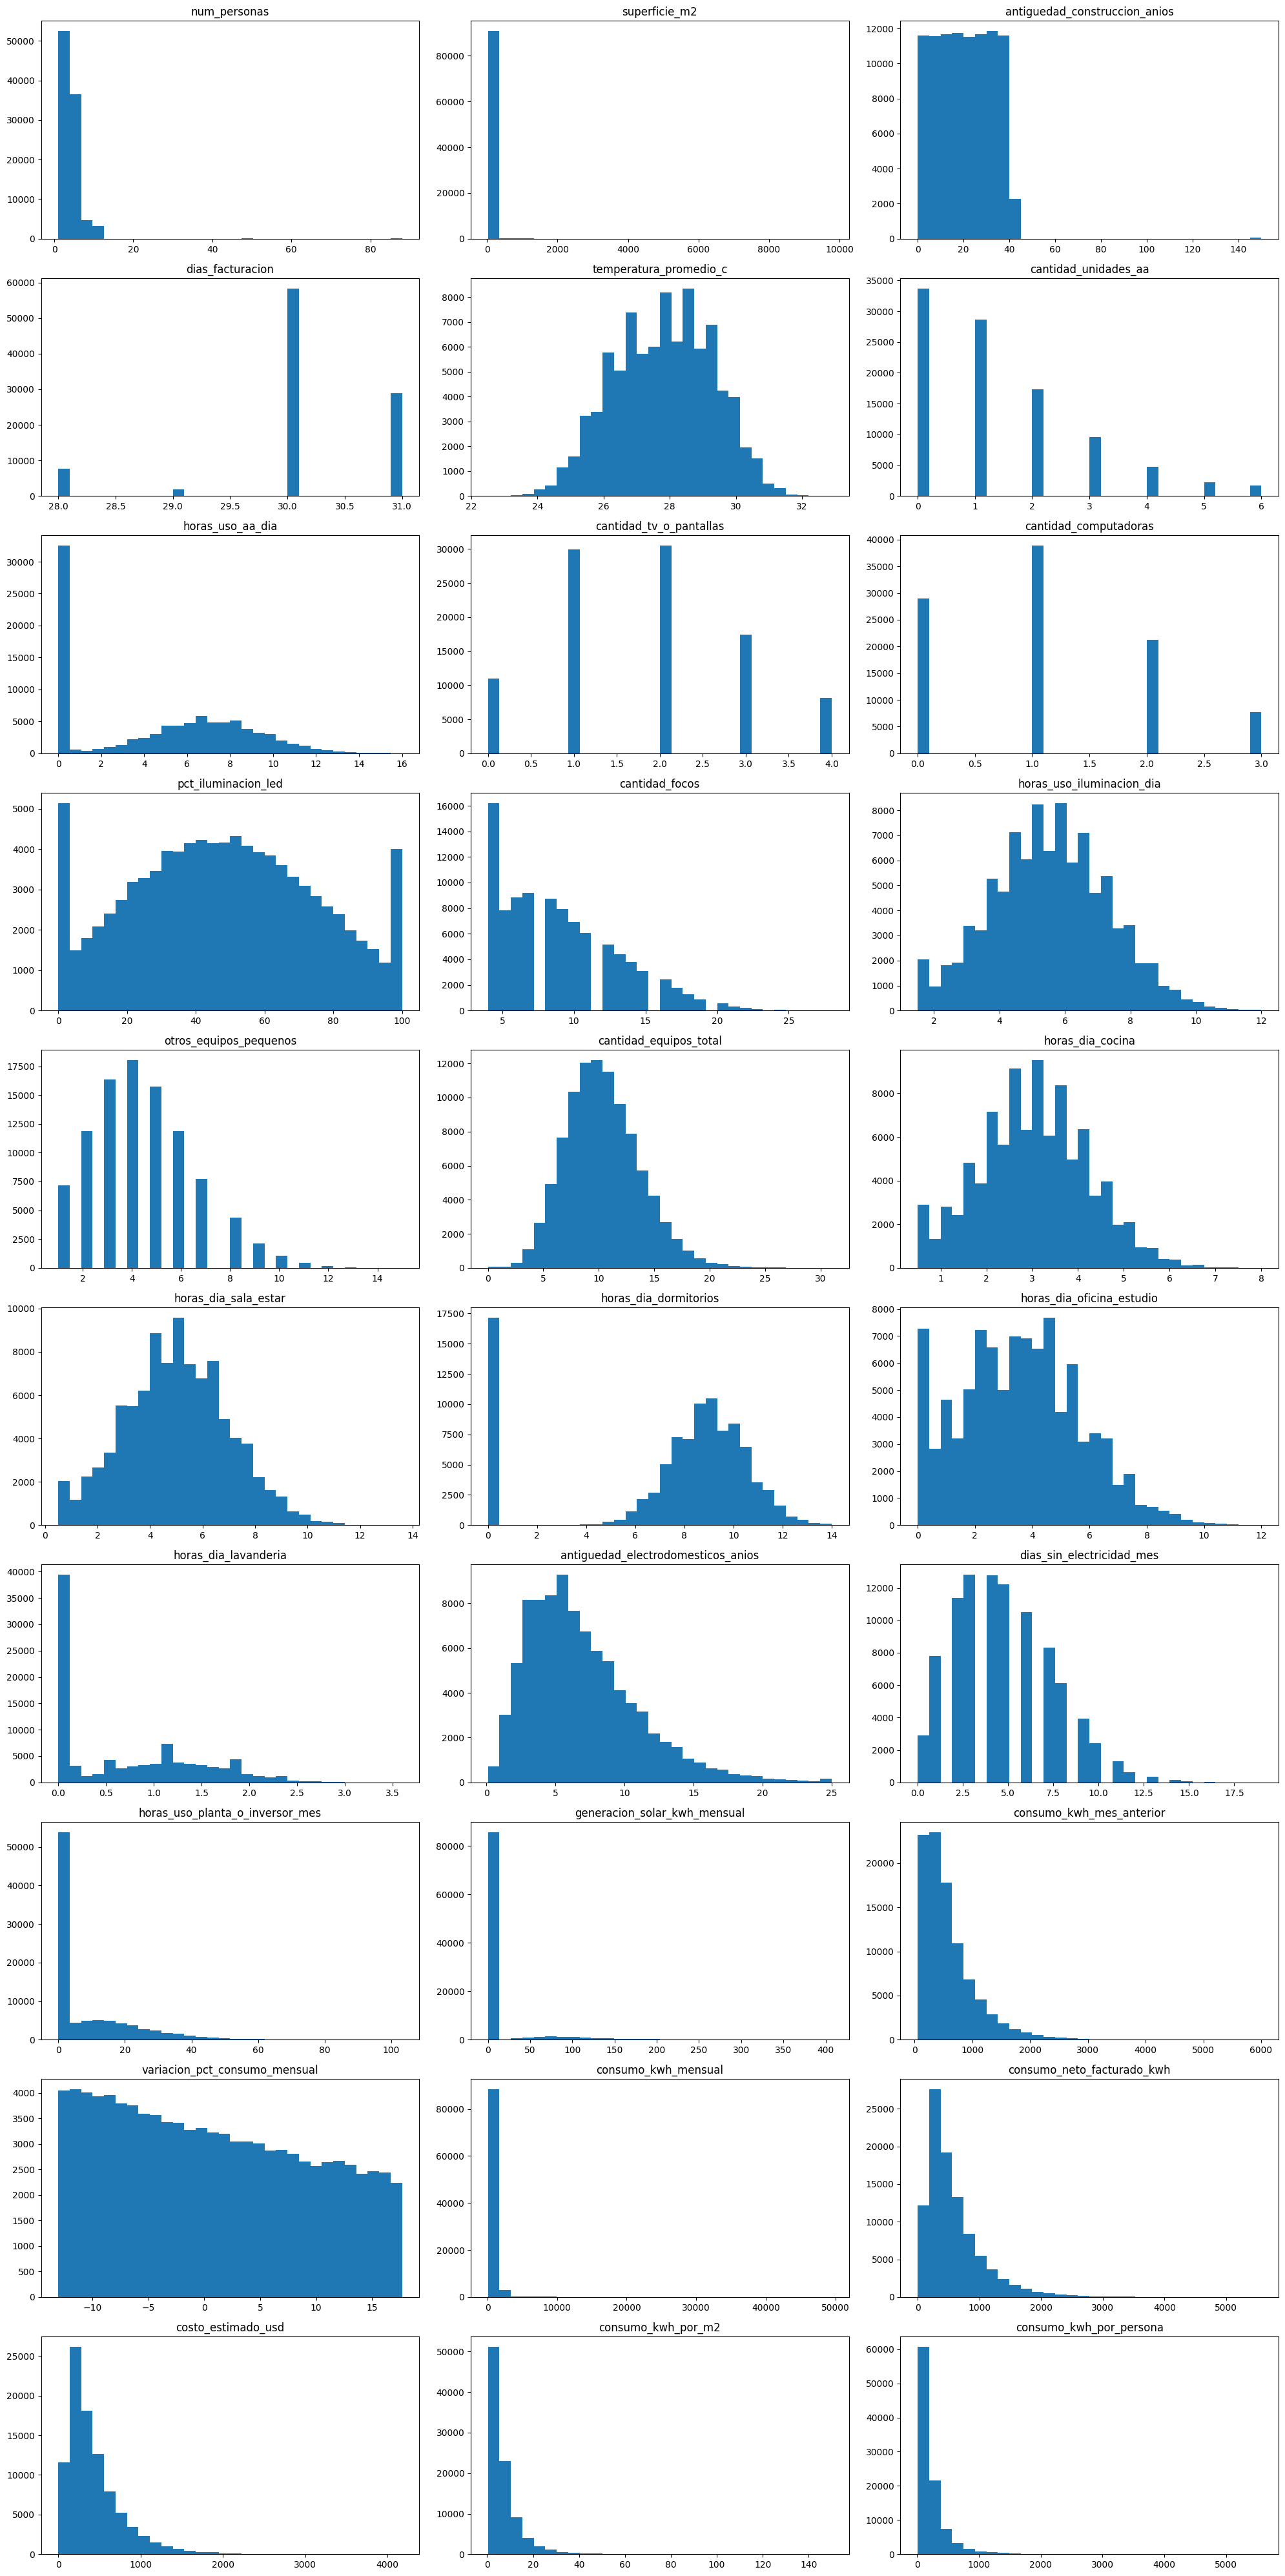


Proceso finalizado correctamente.


In [ ]:
# ==========================================================
# ANÁLISIS DE ASIMETRÍA (SKEWNESS), EXCESO DE CURTOSIS
# E HISTOGRAMAS
# ==========================================================

print("="*80)
print("ASIMETRÍA (SKEWNESS) Y EXCESO DE CURTOSIS")
print("="*80)

# ==========================================================
# PASO 1
# Seleccionar únicamente variables numéricas
# ==========================================================

variables = bd.select_dtypes(
    include=["Int64", "Float64", "int64", "float64"]
).columns

estadisticas = []
variables_excluidas = []

# ==========================================================
# PASO 2
# Calcular Skewness y Curtosis
# ==========================================================

for col in variables:

    # Excluir identificadores
    if col in ["Unnamed: 0", "id_registro"]:
        variables_excluidas.append({
            "Variable": col,
            "Cardinalidad": "-",
            "Motivo": "Variable identificadora"
        })
        continue

    serie = bd[col].dropna().astype(float)

    cardinalidad = serie.nunique()

    # Excluir variables binarias o de baja cardinalidad
    if cardinalidad <= 3:

        variables_excluidas.append({

            "Variable": col,

            "Cardinalidad": int(cardinalidad),

            "Motivo": "Cardinalidad ≤ 3"

        })

        continue

    estadisticas.append({

        "Variable": col,

        "Nulos": int(bd[col].isna().sum()),

        "Coeficiente de Skewness": serie.skew(),

        "Exceso de Curtosis": serie.kurt()

    })

# ==========================================================
# PASO 3
# Crear tabla de resultados
# (Se conservan todos los decimales)
# ==========================================================

df = pd.DataFrame(estadisticas)

# ==========================================================
# PASO 4
# Colorear y formatear resultados
# ==========================================================

def colorear(valor):

    if pd.isna(valor):
        return ""

    elif valor > 0:
        return (
            "background-color:#2E7D32;"
            "color:white;"
            "font-weight:bold;"
        )

    elif valor < 0:
        return (
            "background-color:#1565C0;"
            "color:white;"
            "font-weight:bold;"
        )

    else:
        return (
            "background-color:white;"
            "color:black;"
        )

styled = (
    df.style
    .applymap(
        colorear,
        subset=[
            "Coeficiente de Skewness",
            "Exceso de Curtosis"
        ]
    )
    .format({
        "Coeficiente de Skewness": "{:.2f}",
        "Exceso de Curtosis": "{:.2f}"
    })
)

# ==========================================================
# PASO 5
# Mostrar resultados
# ==========================================================

print("\nTabla de Skewness y Curtosis\n")

display(styled)

# ==========================================================
# PASO 6
# Variables excluidas
# ==========================================================

print("\nVariables excluidas del análisis\n")

if len(variables_excluidas) > 0:

    display(
        pd.DataFrame(variables_excluidas)
    )

else:

    print("No se excluyó ninguna variable.")

print()

print(f"Variables analizadas            : {len(df)}")

print(f"Variables excluidas            : {len(variables_excluidas)}")

# ==========================================================
# PASO 7
# Histogramas
# ==========================================================

print("\n" + "="*80)
print("HISTOGRAMAS")
print("="*80)

variables_hist = df["Variable"].tolist()

bd[variables_hist].hist(

    bins=30,

    figsize=(20, 4*((len(variables_hist)+2)//3)),

    layout=(-1,3),

    grid=False

)

plt.tight_layout()

plt.show()

print("\nProceso finalizado correctamente.")

Apoyándose en la información presentada tanto en la tabla como en los gráficos, se observa un claro predominio de distribuciones con asimetría positiva en la mayoría de las variables evaluadas. Este comportamiento podría ser relevante en etapas posteriores del proyecto, dependiendo del tipo de modelo de aprendizaje automático que se implemente, ya que algunas técnicas asumen distribuciones más simétricas o son sensibles a la presencia de valores extremos. En consecuencia, podría ser necesario aplicar transformaciones que reduzcan la asimetría de los datos, como la transformación logarítmica, antes del entrenamiento del modelo. Por último, la mayoría de los valores de exceso de curtosis demuestran que estas tienen una forma leptocúrtica, lo que se puede expresar como una mayor probabilidad de encontrar valores extremos.

Apoyándose en la información presentada tanto en la tabla como en los gráficos, se observa un claro predominio de distribuciones con asimetría positiva en la mayoría de las variables evaluadas. Este comportamiento podría ser relevante en etapas posteriores del proyecto, dependiendo del tipo de modelo de aprendizaje automático que se implemente, ya que algunas técnicas asumen distribuciones más simétricas o son sensibles a la presencia de valores extremos. En consecuencia, podría ser necesario aplicar transformaciones que reduzcan la asimetría de los datos, como la transformación logarítmica, antes del entrenamiento del modelo. Por último, la mayoría de los valores de exceso de curtosis demuestran que estas tienen una forma leptocúrtica, lo que se puede expresar como una mayor probabilidad de encontrar valores extremos.

## Diagramas de caja (*Boxplots*) para la identificación de valores atípicos

Como parte del Análisis Exploratorio de Datos (EDA), se generó un conjunto de diagramas de caja (*Boxplots*) para las variables numéricas del conjunto de datos. El objetivo de este análisis es representar gráficamente la distribución de cada variable, identificar la dispersión de los datos y detectar la posible presencia de valores atípicos (*outliers*) que puedan influir en los análisis posteriores o en el entrenamiento de modelos de aprendizaje automático.

Inicialmente, el procedimiento identifica automáticamente todas las variables numéricas presentes en el DataFrame `bd`. Posteriormente, se excluyen del análisis aquellas variables cuya representación mediante diagramas de caja no resulta estadísticamente significativa. En particular, se omiten las variables de identificación, como `id_registro`, así como todas las variables cuya cardinalidad es igual o inferior a tres valores distintos. Estas últimas corresponden generalmente a variables binarias o discretas con muy pocos valores posibles, para las cuales un diagrama de caja no proporciona información relevante acerca de la distribución de los datos. Las variables excluidas se registran en una tabla resumen, indicando su cardinalidad y el motivo de su exclusión.

Una vez seleccionadas las variables adecuadas, el procedimiento genera automáticamente un diagrama de caja para cada una de ellas utilizando las funciones de visualización de la biblioteca **Matplotlib**. Cada gráfico resume visualmente la distribución de la variable mediante sus principales medidas de posición y dispersión. La línea central de la caja representa la mediana de la distribución, mientras que los límites inferior y superior de la caja corresponden al primer cuartil (Q1) y al tercer cuartil (Q3), respectivamente. La diferencia entre ambos cuartiles constituye el rango intercuartílico (IQR), el cual representa el intervalo donde se concentra el 50 % central de los datos.

Los denominados "bigotes" del diagrama se extienden hasta los valores más extremos que aún se consideran parte de la distribución de acuerdo con el criterio del rango intercuartílico. Aquellos valores que exceden dichos límites se representan como observaciones individuales y constituyen posibles valores atípicos (*outliers*). Es importante señalar que la presencia de un valor atípico en un diagrama de caja no implica necesariamente un error en los datos, sino únicamente una observación cuya magnitud difiere considerablemente del comportamiento general de la variable. Su tratamiento deberá evaluarse posteriormente considerando el contexto y la naturaleza de la información.

Los diagramas generados se organizan automáticamente dentro de una cuadrícula de tres columnas, cuyo número de filas se adapta dinámicamente a la cantidad de variables analizadas. Esta disposición permite visualizar simultáneamente todas las distribuciones de forma ordenada, facilitando la comparación entre variables y la identificación de patrones comunes de dispersión.

Como resultado del procedimiento se obtiene una tabla con las variables excluidas del análisis y la justificación correspondiente, además de un conjunto de diagramas de caja que permiten evaluar visualmente la dispersión, la tendencia central y la posible existencia de valores atípicos en cada una de las variables cuantitativas del conjunto de datos. Esta información constituye un insumo fundamental para las etapas posteriores del Análisis Exploratorio de Datos y para la definición de estrategias de tratamiento de valores extremos cuando estas resulten necesarias.

BOXPLOTS DE LAS VARIABLES NUMÉRICAS

Variables analizadas : 30
Variables excluidas  : 4

Variables excluidas del análisis:



,Variable,Cardinalidad,Motivo
0,tiene_aire_acondicionado,2,Cardinalidad ≤ 3
1,tiene_calentador_agua_electrico,2,Cardinalidad ≤ 3
2,tiene_lavadora,2,Cardinalidad ≤ 3
3,certificacion_energetica_previa,2,Cardinalidad ≤ 3



BOXPLOTS


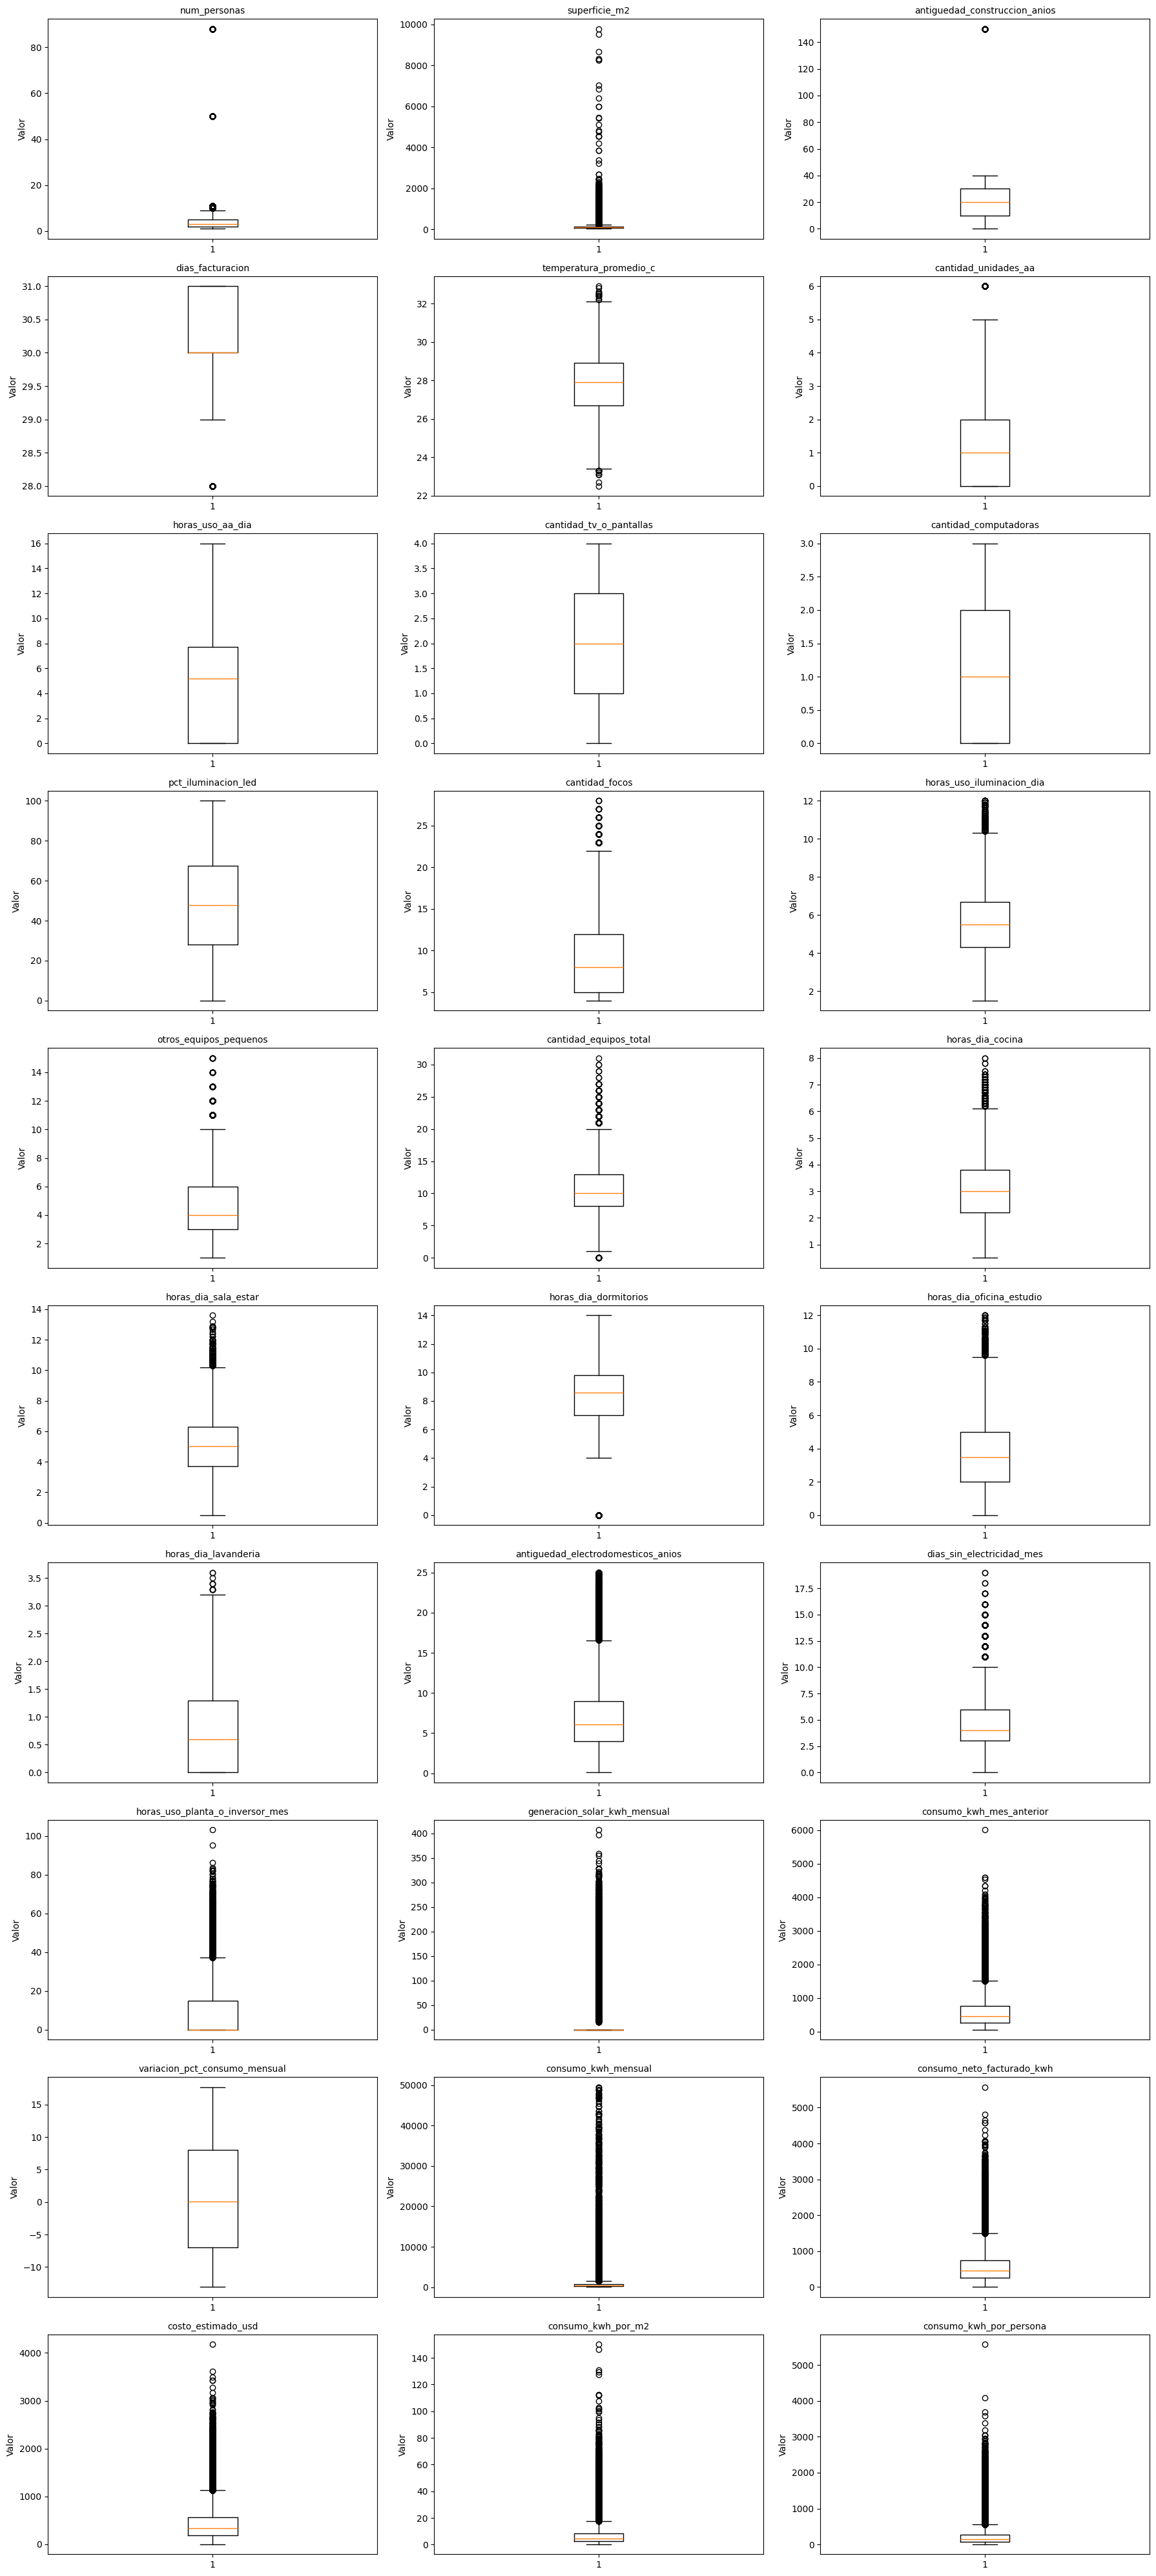


Proceso finalizado correctamente.


In [ ]:
# ==========================================================
# BOXPLOTS DE VARIABLES NUMÉRICAS
# (EXCLUYENDO VARIABLES CATEGÓRICAS Y CARDINALIDAD <= 3)
# ==========================================================

print("="*80)
print("BOXPLOTS DE LAS VARIABLES NUMÉRICAS")
print("="*80)

# ==========================================================
# PASO 1
# Seleccionar únicamente variables numéricas
# ==========================================================

variables = bd.select_dtypes(
    include=["Int64", "Float64", "int64", "float64"]
).columns

variables_boxplot = []
variables_excluidas = []

# ==========================================================
# PASO 2
# Filtrar variables
# ==========================================================

for col in variables:

    # Excluir identificadores
    if col in ["Unnamed: 0", "id_registro"]:

        variables_excluidas.append({

            "Variable": col,

            "Cardinalidad": "-",

            "Motivo": "Variable identificadora"

        })

        continue

    serie = bd[col].dropna()

    cardinalidad = serie.nunique()

    # Excluir variables con poca variabilidad
    if cardinalidad <= 3:

        variables_excluidas.append({

            "Variable": col,

            "Cardinalidad": int(cardinalidad),

            "Motivo": "Cardinalidad ≤ 3"

        })

        continue

    variables_boxplot.append(col)

# ==========================================================
# PASO 3
# Resumen
# ==========================================================

print(f"\nVariables analizadas : {len(variables_boxplot)}")
print(f"Variables excluidas  : {len(variables_excluidas)}")

if len(variables_excluidas) > 0:

    print("\nVariables excluidas del análisis:\n")

    display(
        pd.DataFrame(variables_excluidas)
    )

# ==========================================================
# PASO 4
# Generación automática de Boxplots
# ==========================================================

print("\n" + "="*80)
print("BOXPLOTS")
print("="*80)

n = len(variables_boxplot)

filas = (n + 2) // 3

fig, axes = plt.subplots(
    filas,
    3,
    figsize=(18, filas * 4)
)

axes = axes.flatten()

for i, variable in enumerate(variables_boxplot):

    axes[i].boxplot(
        bd[variable].dropna(),
        vert=True,
        patch_artist=False
    )

    axes[i].set_title(variable, fontsize=10)

    axes[i].set_ylabel("Valor")

# Eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

print("\nProceso finalizado correctamente.")

De acuerdo con la información presentada en los diagramas de caja y bigotes, se evidencia la presencia de múltiples valores atípicos (outliers), principalmente por encima del límite superior definido por Q3 + 1.5 × RIC. Estos valores podrían ser relevantes en etapas posteriores del proyecto, ya que su presencia puede afectar el desempeño de determinados modelos de aprendizaje automático, especialmente aquellos basados en medidas de distancia, como K-Nearest Neighbors (KNN). En contraste, modelos basados en árboles de decisión, como Random Forest, suelen ser más robustos frente a este tipo de observaciones.

## Análisis de frecuencias de las variables categóricas

Como parte del Análisis Exploratorio de Datos (EDA), se realizó un análisis de frecuencias sobre todas las variables categóricas presentes en el conjunto de datos. El objetivo de este procedimiento es describir la distribución de las categorías observadas en cada variable, identificar posibles desbalances entre clases, detectar categorías poco representadas y evaluar la presencia de valores faltantes antes de aplicar técnicas de imputación o de transformación de variables.

Inicialmente, el procedimiento identifica automáticamente todas las variables categóricas almacenadas en el DataFrame `bd`, considerando aquellas cuyo tipo de dato corresponde a texto (`object` o `string`) o categorías (`category`). Esta selección se realiza de manera automática, permitiendo que el análisis se adapte a modificaciones futuras del conjunto de datos sin necesidad de actualizar manualmente la lista de variables.

Posteriormente, para cada variable categórica se calcula la frecuencia absoluta de cada una de sus categorías mediante el conteo del número de observaciones que pertenecen a cada valor distinto. De forma complementaria, se calcula la frecuencia relativa expresada como porcentaje respecto al número total de registros del conjunto de datos. Ambas medidas permiten evaluar no solamente el número de observaciones presentes en cada categoría, sino también su importancia relativa dentro de la distribución completa de la variable.

El procedimiento incorpora los valores faltantes (`NaN`) como una categoría adicional dentro de cada tabla de frecuencias. Esta decisión metodológica permite cuantificar de manera explícita la proporción de datos ausentes en cada variable categórica, proporcionando información relevante para la etapa posterior de imputación de valores faltantes y facilitando la evaluación de la calidad del conjunto de datos.

Los resultados obtenidos se organizan en una tabla independiente para cada variable categórica. Cada tabla presenta tres columnas: la categoría observada, su frecuencia absoluta y su frecuencia relativa expresada en porcentaje. Los porcentajes se muestran redondeados a dos cifras decimales únicamente para fines de presentación, conservándose internamente toda la precisión de los cálculos realizados.

Finalmente, el procedimiento muestra un resumen indicando el número total de variables categóricas analizadas. En conjunto, estas tablas permiten identificar categorías dominantes, categorías poco frecuentes, posibles desbalances entre clases y la existencia de valores faltantes, proporcionando una caracterización completa de las variables cualitativas antes de continuar con las etapas posteriores del Análisis Exploratorio de Datos y la preparación del conjunto de datos para el entrenamiento de modelos de aprendizaje automático.

In [ ]:

# ==========================================================
# TABLAS DE FRECUENCIAS PARA VARIABLES CATEGÓRICAS
# ==========================================================

print("="*80)
print("TABLAS DE FRECUENCIA DE VARIABLES CATEGÓRICAS")
print("="*80)

# ==========================================================
# PASO 1
# Seleccionar variables categóricas
# ==========================================================

variables_categoricas = bd.select_dtypes(
    include=["object", "string", "category"]
).columns

print(f"\nVariables categóricas encontradas: {len(variables_categoricas)}")

# ==========================================================
# PASO 2
# Generar tabla de frecuencias para cada variable
# ==========================================================

for variable in variables_categoricas:

    print("\n")
    print("="*80)
    print(f"VARIABLE: {variable}")
    print("="*80)

    frecuencia_abs = (
        bd[variable]
        .value_counts(dropna=False)
    )

    frecuencia_rel = (
        bd[variable]
        .value_counts(dropna=False, normalize=True)
        * 100
    )

    tabla = pd.DataFrame({

        "Categoría": frecuencia_abs.index.astype("string"),

        "Frecuencia absoluta": frecuencia_abs.values,

        "Frecuencia relativa (%)": frecuencia_rel.values

    })

    tabla["Frecuencia relativa (%)"] = (
        tabla["Frecuencia relativa (%)"]
        .round(2)
    )

    display(tabla)

# ==========================================================
# PASO 3
# Resumen
# ==========================================================

print("\n" + "="*80)
print("RESUMEN")
print("="*80)

print(f"Variables categóricas analizadas: {len(variables_categoricas)}")

print("\nProceso finalizado correctamente.")

TABLAS DE FRECUENCIA DE VARIABLES CATEGÓRICAS

Variables categóricas encontradas: 9


VARIABLE: id_registro


,Categoría,Frecuencia absoluta,Frecuencia relativa (%)
0,<NA>,144,0.15
1,REG-019173,3,0.00
2,REG-028030,3,0.00
3,REG-017402,3,0.00
4,REG-056986,3,0.00
...,...,...,...
96956,REG-049819,1,0.00
96957,REG_021468,1,0.00
96958,REG-014468,1,0.00
96959,REG-019829,1,0.00




VARIABLE: tipo_inmueble


,Categoría,Frecuencia absoluta,Frecuencia relativa (%)
0,Apartamento,41113,41.52
1,Casa Unifamiliar,39239,39.63
2,Pequeño Establecimiento Comercial,17544,17.72
3,<NA>,1128,1.14




VARIABLE: zona


...



VARIABLE: fuente_energia_secundaria


,Categoría,Frecuencia absoluta,Frecuencia relativa (%)
0,Ninguna,52997,53.52
1,Planta Eléctrica,19094,19.28
2,Inversor con baterías,14160,14.30
3,Panel Solar,9669,9.76
4,<NA>,3104,3.13




VARIABLE: perfil_energetico


,Categoría,Frecuencia absoluta,Frecuencia relativa (%)
0,Eficiente,33739,34.07
1,Moderado,33620,33.95
2,Ineficiente,29062,29.35
3,<NA>,2603,2.63



RESUMEN
Variables categóricas analizadas: 9

Proceso finalizado correctamente.


Se detecta cierto desbalance en la representación de algunas categorías dentro de determinadas variables. Por ejemplo, en la variable fuente_energia_secundaria, la categoría Panel Solar presenta una frecuencia de apenas 9,77 % en comparación con las demás categorías con una presencias desde 14.34% a 53.56%.

Respecto de la variable objetivo, perfil_energetico, se observa una distribución relativamente equilibrada entre sus categorías, con diferencias inferiores al 5%. Esto podría indicar que no es necesario aplicar técnicas adicionales de balanceo de clases.

Sin embargo, antes de tomar una decisión definitiva, conviene analizar la distribución de la variable objetivo en relación con las demás características del conjunto de datos.


# Conclusion

En resumen, la mayoría de las variables del conjunto de datos presentan una alta heterogeneidad, evidenciada por coeficientes de variación elevados. Asimismo, predomina una asimetría positiva en sus distribuciones, lo que indica la presencia de una cola más extensa hacia los valores altos. Como consecuencia, se observa una cantidad considerable de valores atípicos, principalmente en el extremo superior de las distribuciones, lo que puede reducir la representatividad de la media como medida de tendencia central.

Por otro lado, varias variables presentan una distribución leptocúrtica, caracterizada por una mayor concentración de observaciones alrededor de la media y colas más pesadas que las de una distribución normal. Este comportamiento refuerza la evidencia de la presencia de valores atípicos y es consistente con la elevada variabilidad observada mediante el coeficiente de variación. Finalmente es ideal considerar estos antecedentes a la hora de definir un proceso de imputación de datos nulos o durante la elección de variables para el entrenamiento de un modelo.